# Test the statistical method for different scenario

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
c0 ={'acc':'#941717', 'cor':'#388E3C','ggd':'#42A5F5', 'wd':'#FFA000', 'sum':'lightgrey'}
plt.rcParams["hatch.linewidth"] = 8
from diagnosis import compute_mean_square
from cstes import U

In [2]:
N=100000 # nb coloc

In [4]:
closure_vars = ['ACC*', 'COR*', 'GGD*', 'WD*', 'S*', 'sigma*'] + ['B*_'+v for v in ['acc', 'cor', 'ggd', 'wd']] + ['E*_'+v for v in ['acc', 'cor', 'ggd', 'wd']] + ['X*_acc_cor', 'X*_acc_ggd', 'X*_acc_wd', 'X*_cor_ggd', 'X*_cor_wd', 'X*_ggd_wd'] + ['D*_cyclo', 'D*_anticyclo']

def compute_mean_square_1D(ds):
    """ Compute closure stats
    ds : dataset containing terms values for all row_numbers
    dirname : directions of the reconstruction
    """

    closure_vars_=closure_vars
    
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']
    if 'meancor' in ds :
        print('ok')
        var += ['meancor', 'meanggd']
        VAR += ['meancor'.upper(), 'meanggd'.upper()]
        closure_vars_ = closure_vars +['MEANCOR*', 'MEANGGD*']
        
    dss = (ds[[v for v in var]]**2).rename({var[i] : VAR[i] for i in range(len(var))})
    dss['sigma'] = dss['ACC'] + dss['COR'] + dss['GGD'] + dss['WD']
    
    nb_coloc = len(ds.row_number)
    
    #Balanced and error

    for v in ['acc', 'cor', 'ggd', 'wd'] : 
        dss['B'+'_'+v] = -((ds[v]*ds['exc'+'_'+v]))
        dss['E'+'_'+v] = ((ds[v]*ds['sum']))
            
    #pairs contributions
    for v in [v for v in ds if 'prod' in v]:
        dss[v.replace('prod', 'X')]=-2*ds[v]

    # Cyclo/anticyclo contribution
    dss['D'+'_cyclo'] = -2 *(ds['acc']+ds['cor'])*ds['ggd']
    dss['D'+'_anticyclo'] = -2 *(ds['acc']+ds['ggd'])*ds['cor']

    # Mean
    dsm = dss.mean('row_number')
    
    # Add errors central limit
    dsse = (2*dss.std('row_number')/np.sqrt(nb_coloc)).rename({v:'ser__'+v for v in list(dss.keys())})

    dss = xr.merge([dsm, dsse])

    #Mean geostrophics corrections :
    if 'meancor' in ds :
        print('geostrophic mean corrections')

        for v in ['cor', 'ggd']:
            dss[v.upper() ] = dss[v.upper() ] + dss['MEAN'+ v.upper() ]
            dss['B'+'_'+v] = dss['B'+'_'+v] + dss['MEAN'+ v.upper() ]
            dss['X'+'_cor_ggd'] = dss['X'+'_cor_ggd'] + 2*dss['MEAN'+ v.upper() ]
        for v in ['cor', 'ggd']:
            dss[v.upper()] =  dss[v.upper() + dirname[0]]
            dss['B_'+v] = dss['B'+'_'+v] 
            dss['X_cor_ggd'] = dss['X'+'_cor_ggd']
        
    #end
    from diagnosis import assign_attrs
    dss = assign_attrs(dss,[''])
    return dss

def build_dataset(a, b, c, d, row, mean_cor = True):
    ds = xr.Dataset(
        data_vars=dict(
            acc=("row_number", a),
            cor=("row_number", b),
            ggd=("row_number", c),
            wd=("row_number", d),
        ), 
        coords=dict(row_number=("row_number", row)
                   )
    )
    
    if mean_cor :
        ds = ds-ds.mean(dim = 'row_number')
        print('apply mean correction')
        
    ds['sum'] = ds.acc + ds.cor + ds.ggd +ds.wd

    # simple var + sum- one term
    for v in ['acc', 'cor', 'ggd', 'wd'] :
        ds['exc_'+v] = ds['sum']-ds[v]

    #2 by 2 product    
    import itertools  
    couple = list(itertools.combinations(['acc', 'cor', 'ggd', 'wd'],2))
    for c in couple : 
        ds['prod'+'_'+'_'.join(c)] = ds[c[0]] * ds[c[1]]
    
    return ds

def plot_terms(ds):
    fig, axs = plt.subplots(1, 5, sharey=True, frameon=False, figsize=(10,3))
    i=0
    for var in ['acc', 'cor','ggd','wd', 'sum']:
        ds[var].plot(ax=axs[i], color = c0[var])
        i+=1
    for ax in axs :
        ax.grid()


def plot_diag(fig, ax, ds2):
    plt.rcParams["axes.edgecolor"] = "k"
    var = ['acc', 'cor', 'ggd', 'wd']
    i=0
    for v in var:
        # total MS
        ax.bar(i, ds2[v.upper()], color=c0[v], alpha=0.5)
    
        #B and E
        if ds2['B_'+v] > 0 : 
            ax.bar(i, ds2['B_'+v], color=c0[v], width=0.7)
            if ds2['E_'+v]< 0 : ax.bar(i, ds2['E_'+v], color='lightgrey', width=0.7)
            else : ax.bar(i, ds2['E_'+v],bottom = ds2['B_'+v], color='lightgrey', width=0.7)
        else :
            ax.bar(i, ds2['B_'+v], color=c0[v], width=0.7)
            if ds2['E_'+v]>0 : ax.bar(i, ds2['E_'+v], color='lightgrey', width=0.7)
            else : ax.bar(i, ds2['E_'+v],bottom = ds2['B_'+v], color='lightgrey', width=0.7)
                
        #X
        X_var = [x for x in ds2 if (('X_' in x)&(v in x)&('ser_' not in x))]
        pos_X = [ x for x in X_var if ds2[x]>0]
        neg_X = [ x for x in X_var if x not in pos_X]
    
        sum_posX = 0
        for X in pos_X :
            xc =X.replace('X_', '').split('_')
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(i, ds2[X]/2, bottom = sum_posX, color = c0[xc[1]], hatch="/", width=0.5)
            sum_posX += ds2[X]/2
    
        sum_negX = 0
        for X in neg_X :
            xc =X.replace('X_', '').split('_')
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(i, ds2[X]/2, bottom = sum_negX, color = c0[xc[1]], hatch="/", width=0.5)
            sum_negX += ds2[X]/2
        i+=1
    ax.bar(i, ds2['S'], color = 'lightgrey')
    ax.grid()
    

def plot_total_diag(a, b, c, d, row, mean_cor):
    
    ds = build_dataset(a, b, c, d, row, mean_cor)
    
    ds = ds.dropna(dim='row_number')

    ds['row_number'] = ds['row_number'].assign_attrs({'long_name':'Colocations'})
    ds['acc'] = ds['acc'].assign_attrs({'long_name':'A', 'unit':r'$\gamma$'})
    ds['cor'] = ds['cor'].assign_attrs({'long_name':'B', 'unit':r'$\gamma$'})
    ds['ggd'] = ds['ggd'].assign_attrs({'long_name':'C', 'unit':r'$\gamma$'})
    ds['wd'] = ds['wd'].assign_attrs({'long_name':'D', 'unit':r'$\gamma$'})
    ds['sum'] = ds['sum'].assign_attrs({'long_name':'Residual', 'unit':r'$\gamma$'})

    ds2 = compute_mean_square_1D(ds)

    from matplotlib.gridspec import GridSpec
    fig = plt.figure( frameon=False, figsize = (13, 6))
    gs = GridSpec(2, 5, figure=fig)

    # Visualize row series
    i=0
    ax0 = fig.add_subplot(gs[0, i])
    for var in ['acc', 'cor','ggd','wd', 'sum']:
        ax = fig.add_subplot(gs[0, i], sharey=ax0)
        ds[var].plot(ax=ax, color = c0[var])
        ax.axhline(ds[var].mean(dim='row_number'), ls = '--', color='k')
        ax.grid()
        i+=1
    # Reconstruction data
    ax = fig.add_subplot(gs[1, :])
    plot_diag(fig, ax, ds2)
    ax.set_xticks(ticks = np.arange(5),labels = ['A', 'B', 'C', 'D','Residual'] )
    ax.set_ylabel(r'[$\gamma^2$]')
    fig.tight_layout()
    
    return ds, ds2

__________________________
# 1. No errors
## 1.1. Gradient wind balance

$$u_{\theta} = -\frac{1}{2}fr \pm \frac{1}{2}fr\sqrt{1+\frac{4}{fr}u_g} $$

$$\frac{u_{\theta}^2}{r} + fu_{\theta} = fu_g$$

$$u_g = \frac{fr}{4}[(\frac{2u_{\theta}}{fr}-1)^2-1]$$

In [5]:
def compute_u_theta(f, r, ug):
    a = -1/2*f*r 
    b = 1/2*f*r*np.sqrt(1+4*ug/f/r)
    return a-b, a+b
def compute_ug(f, r, utheta):
    return f*r/4*((2*utheta/f/r+1)**2-1)

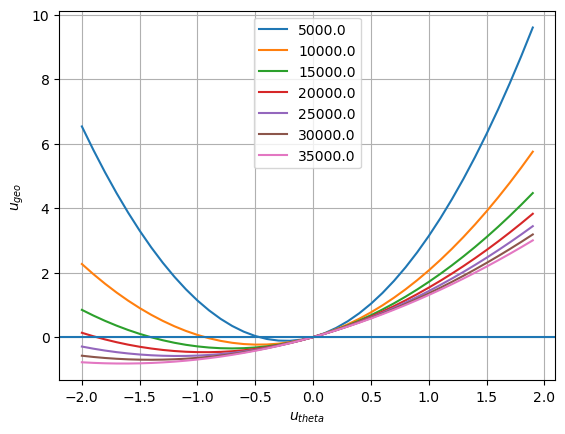

In [52]:
lat=40
ut = np.arange(-2, 2, 0.1)
f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)
R = np.arange(5e3, 40e3, 5e3)
UG = []
for r in R:
    UG.append(compute_ug(f, r, ut))

fig, ax = plt.subplots(frameon=False, )
i=0
for r in R:
    ax.plot(ut,UG[i], label=r)
    i+=1
    
ax.axhline(0)
ax.set_ylabel(r'$u_{geo}$')
ax.set_xlabel(r'$u_{theta}$')
ax.legend()
ax.grid()

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_57725/3615015856.py:3: RuntimeWarning: invalid value encountered in sqrt
  b = 1/2*f*r*np.sqrt(1+4*ug/f/r)


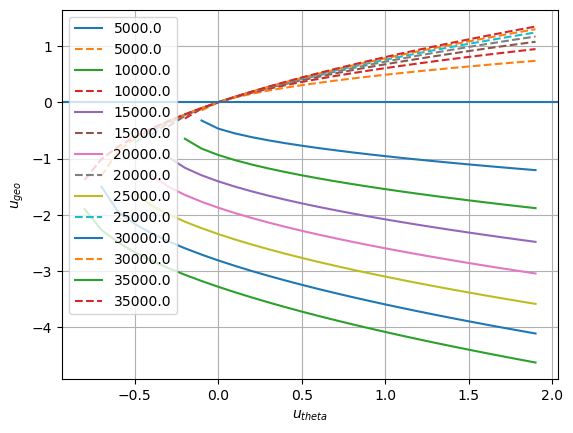

In [62]:
lat=40
ug = np.arange(-2, 2, 0.1)
f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)
R = np.arange(5e3, 40e3, 5e3)
UT = []
for r in R:
    UT.append(compute_u_theta(f, r, ut))

fig, ax = plt.subplots(frameon=False, )
i=0
for r in R:
    ax.plot(ug,UT[i][0], label=r)
    ax.plot(ug,UT[i][1], label=r,ls='--')
    i+=1
    
ax.axhline(0)
ax.set_ylabel(r'$u_{geo}$')
ax.set_xlabel(r'$u_{theta}$')
ax.legend()
ax.grid()

apply mean correction


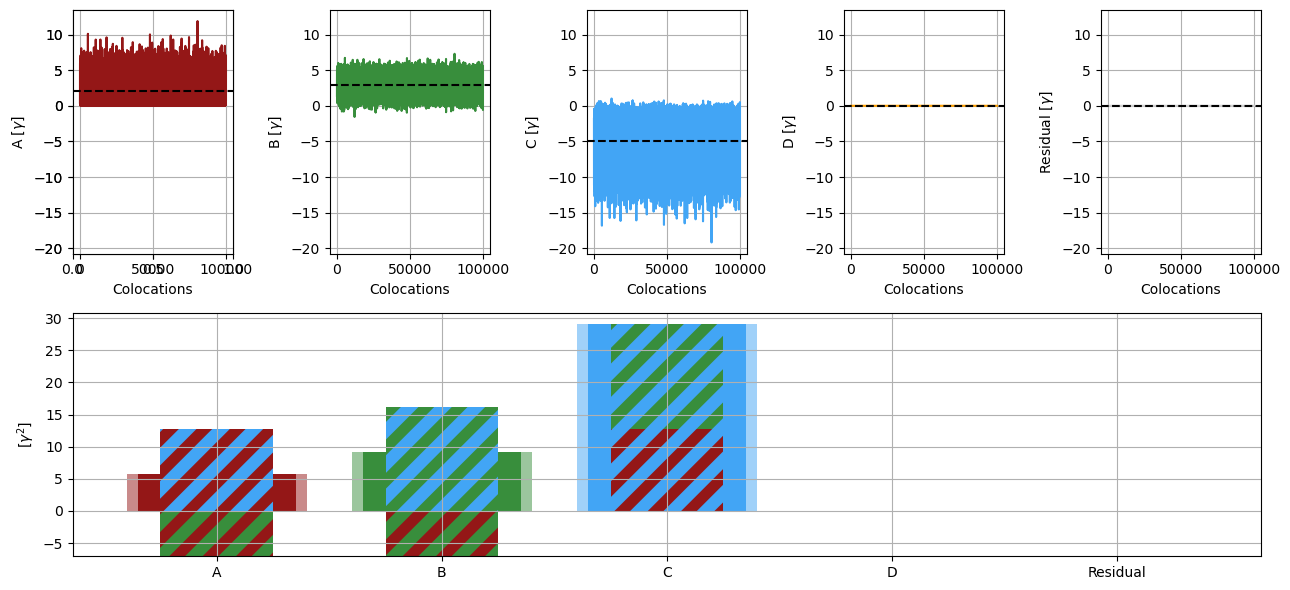

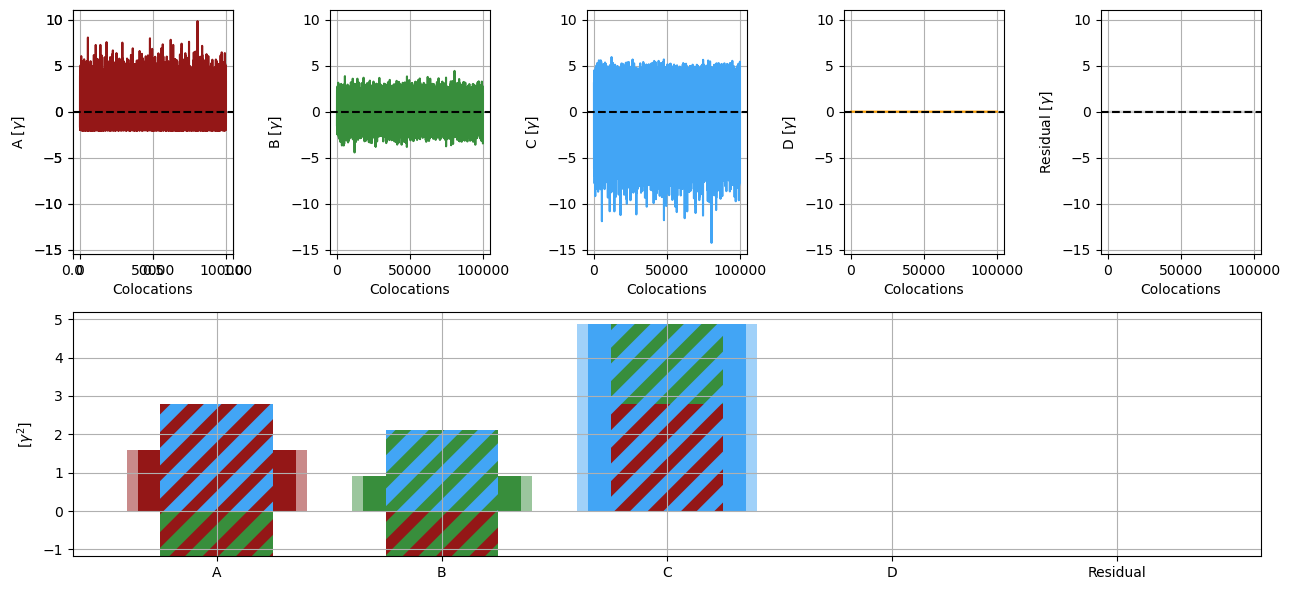

In [63]:
N= 100000
row = np.arange(0, N)

lat = 40#np.random.uniform(10,60, N)#lat
r = 5e3#np.random.normal(10e3,2.5e3, N)#rayon
f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)
utheta = np.random.normal(0.3, 0.1, N)
ug = compute_ug(f, r, utheta)

a = utheta**2/r/U
b = f*utheta/U
c = -f*ug/U
d = np.random.normal(0,0, N)

ds, ds2 = plot_total_diag(a, b, c, d, row, mean_cor=False)
ds, ds2 = plot_total_diag(a, b, c, d, row, mean_cor=True)

apply mean correction


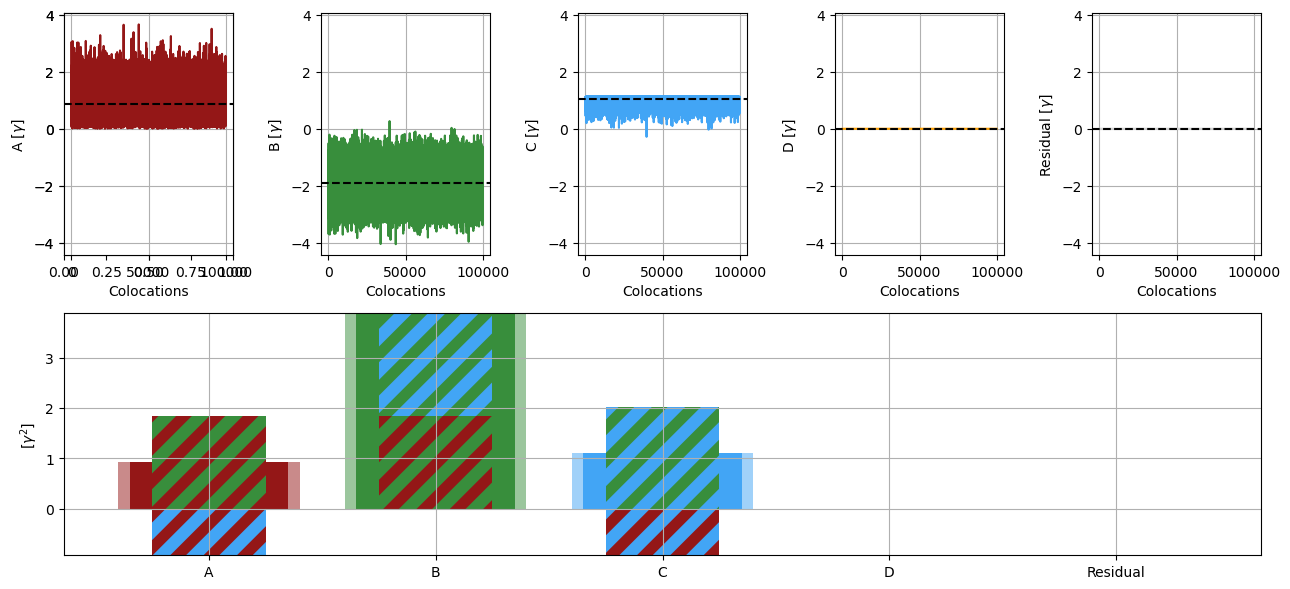

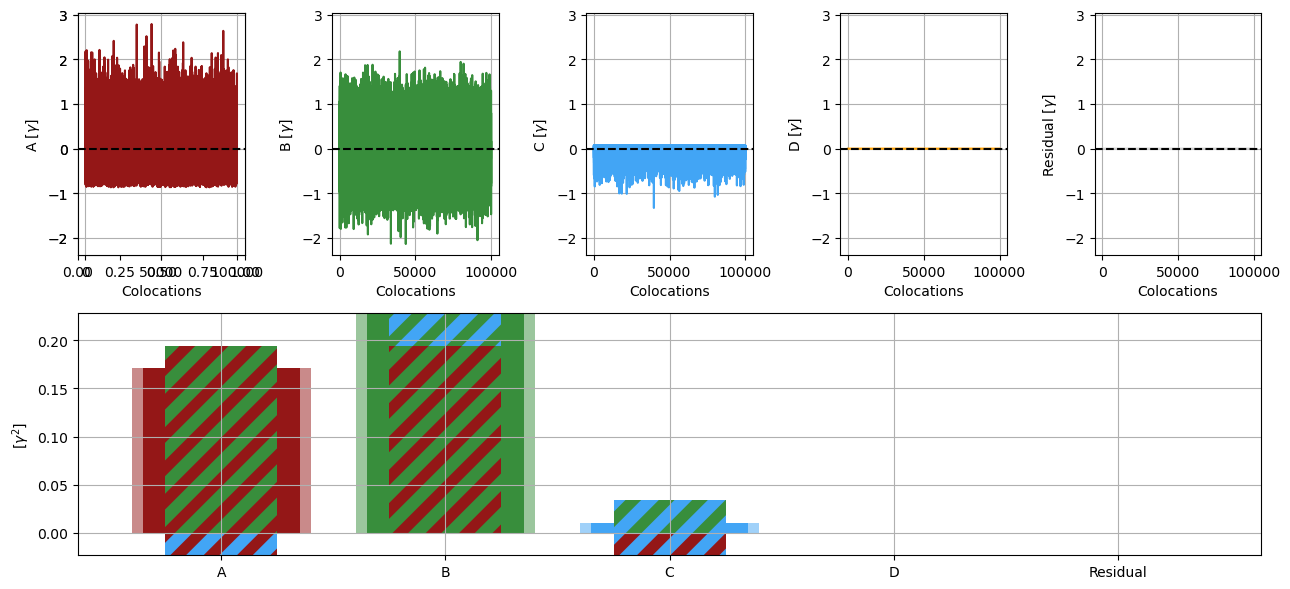

In [65]:
N= 100000
row = np.arange(0, N)

lat = 40#np.random.uniform(10,60, N)#lat
r = 5e3#np.random.normal(10e3,2.5e3, N)#rayon
f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)
utheta = np.random.normal(-0.2,0.05, N)
ug = compute_ug(f, r, utheta)

a = utheta**2/r/U
b = f*utheta/U
c = -f*ug/U
d = np.random.normal(0,0, N)

ds, ds2 = plot_total_diag(a, b, c, d, row, mean_cor=False)
ds, ds2 = plot_total_diag(a, b, c, d, row, mean_cor=True)

apply mean correction


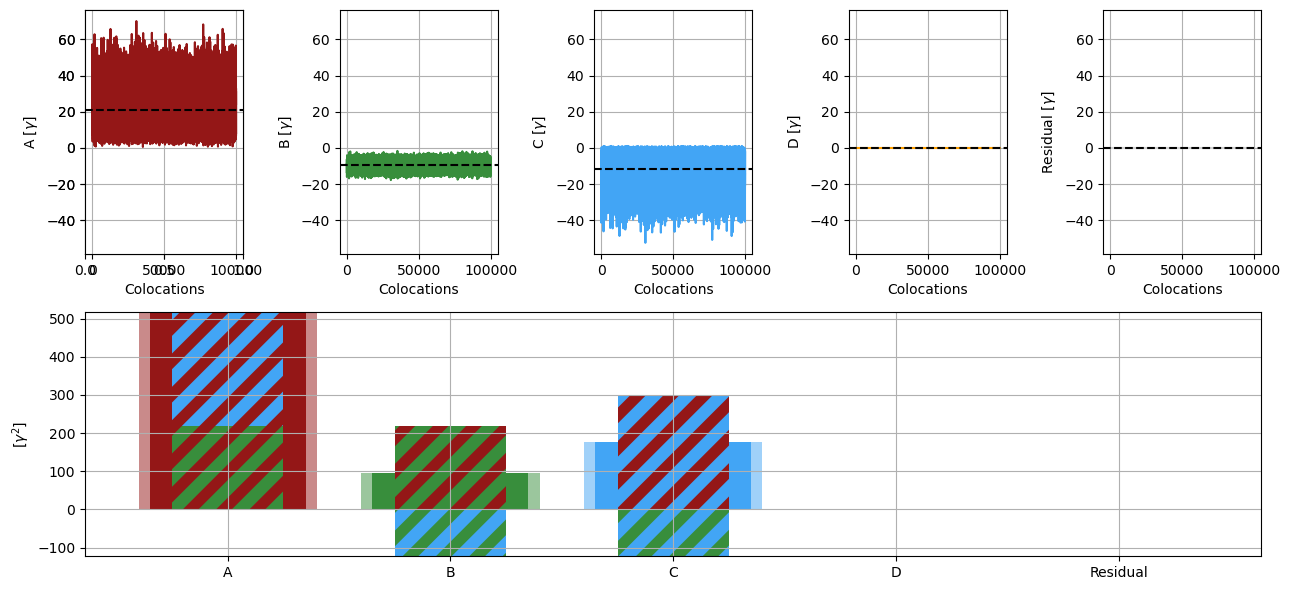

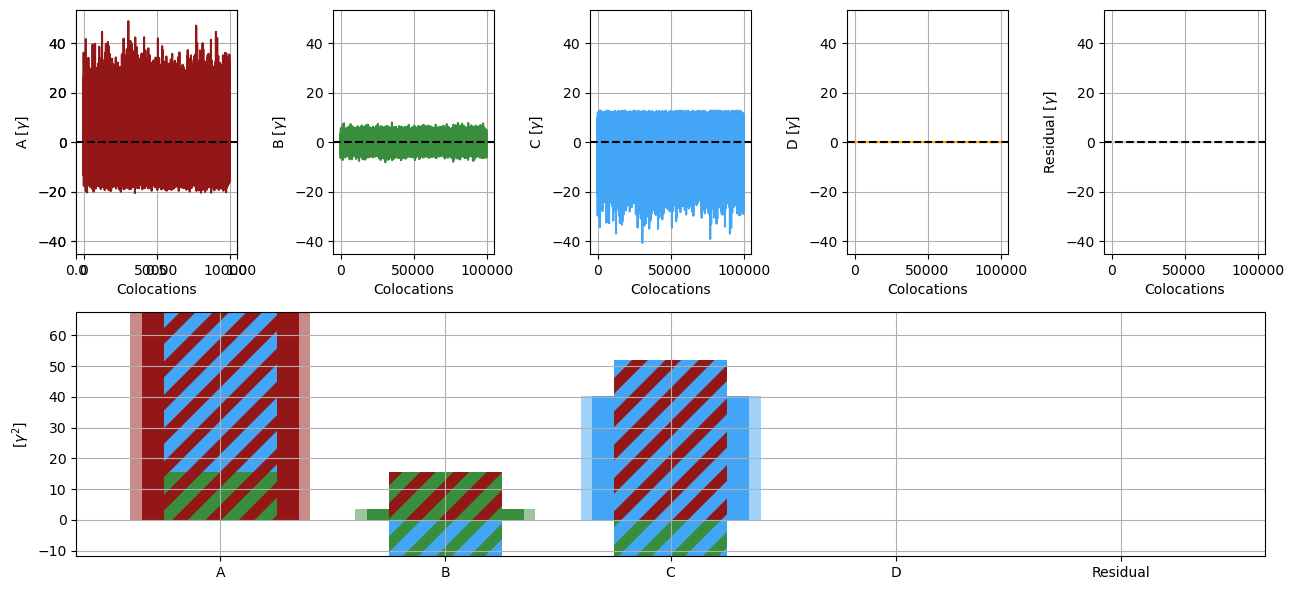

In [67]:
N= 100000
row = np.arange(0, N)

lat = 40#np.random.uniform(10,60, N)#lat
r = 5e3#np.random.normal(10e3,2.5e3, N)#rayon
f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)
utheta = np.random.normal(-1, 0.2, N)
ug = compute_ug(f, r, utheta)

a = utheta**2/r/U
b = f*utheta/U
c = -f*ug/U
d = np.random.normal(0,0, N)

ds, ds2 = plot_total_diag(a, b, c, d, row, mean_cor=False)
ds, ds2 = plot_total_diag(a, b, c, d, row, mean_cor=True)

$$ \frac{4u_g}{fr}>-1 $$

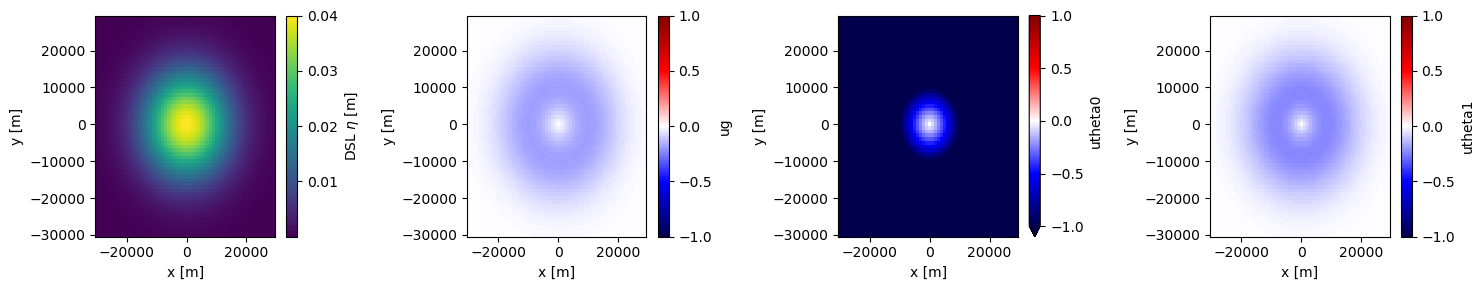

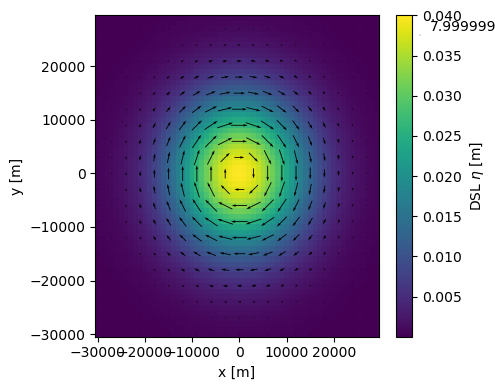

In [97]:
import numpy as np
# define normalized 2D gaussian
def gaus2d(x=0, y=0, mx=0, my=0, sx=1, sy=1):
    return 1. / (2. * np.pi * sx * sy) * np.exp(-((x - mx)**2. / (2. * sx**2.) + (y - my)**2. / (2. * sy**2.)))

def create_champ(L, std, lat, dsl_amp):
    x = np.arange(-L, L, 1e3)
    y = np.arange(-L, L, 1e3)

    X, Y = np.meshgrid(x, y) # get 2D variables instead of 1D
    z = gaus2d(X, Y, mx=0, my=0, sx=10e3, sy=10e3)
    z = z/z.max()*4e-2


    ds = xr.Dataset(
        data_vars=dict(
            eta=(["y","x"], z),
        ), 
        coords=dict( y=("y", y), x=("x", x),
                   ))

    ds['eta'] = ds['eta'].assign_attrs({'long_name':r'DSL $\eta$', 'unit':'m'})
    ds['x'] = ds['x'].assign_attrs({'unit':'m'})
    ds['y'] = ds['y'].assign_attrs({'unit':'m'})

    f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)
    ds['r'] = np.sqrt(ds.x**2+ds.y**2)
    ds['cos'] = (ds.x/ds.r)
    ds['sin'] = (ds.y/ds.r)

    ds['dxeta'] = ds['eta'].differentiate('x')
    ds['dyeta'] = ds['eta'].differentiate('y')
    ds['r'] = np.sqrt(ds.x**2+ds.y**2)
    ds['dreta'] = ds.dxeta*ds.cos + ds.dyeta*ds.sin

    ds['ugx'] = 9.81/f*ds.dxeta
    ds['ugy'] = 9.81/f*ds.dyeta
    ds['ug'] = 9.81/f*ds.dreta

    def compute_u_theta(f, r, ug):
        a = -1/2*f*r 
        b = 1/2*f*r*np.sqrt(1+4*ug/f/r)
        return a-b, a+b
    
    ds['utheta0'] = compute_u_theta(f, ds.r, ds.ug)[0]
    ds['utheta1'] = compute_u_theta(f, ds.r, ds.ug)[1]
    ds['utheta1x'] = ds.utheta1*(-ds.sin)
    ds['utheta1y'] = ds.utheta1*ds.cos
    ds = ds.transpose('y','x')

    ds['accx'] = ds.utheta1x**2/ds.r
    ds['accy'] = ds.utheta1y**2/ds.r
    ds['corx'] = - f*ds.utheta1y
    ds['cory'] = f*ds.utheta1x
    ds['ggdx'] = -g*ds.dxeta
    ds['ggdy'] = -g*ds.dyeta
    


kwargs = {'vmin':-1, 'vmax':1, 'cmap':'seismic'}
fig, axs = plt.subplots(1,4, frameon=False, figsize=(15, 3))
ds.eta.plot(ax=axs[0])
ds.ug.plot(ax=axs[1], **kwargs)
ds.utheta0.plot(ax=axs[2], **kwargs)
ds.utheta1.plot(ax=axs[3], **kwargs)
fig.tight_layout()

fig, axs = plt.subplots(1,1, frameon=False, figsize=(5, 4))
ds.eta.plot(ax=axs)
a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y',scale=4, ax=axs)
#ds.ug.plot(ax=axs[1], **kwargs)
#ds.utheta0.plot(ax=axs[2], **kwargs)
#ds.utheta1.plot(ax=axs[3], **kwargs)
fig.tight_layout()

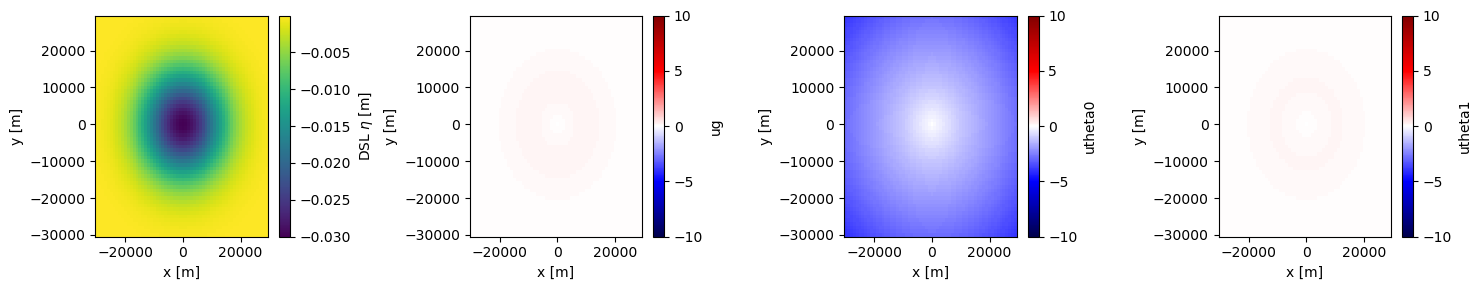

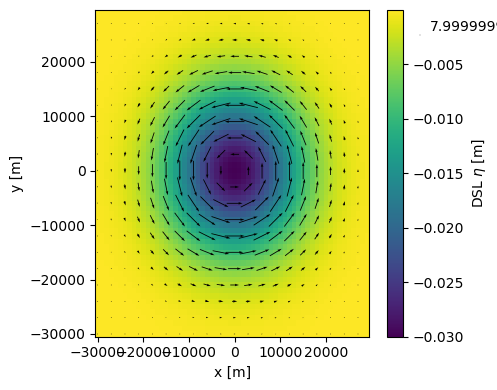

In [98]:
import numpy as np
# define normalized 2D gaussian
def gaus2d(x=0, y=0, mx=0, my=0, sx=1, sy=1):
    return 1. / (2. * np.pi * sx * sy) * np.exp(-((x - mx)**2. / (2. * sx**2.) + (y - my)**2. / (2. * sy**2.)))

L = 30e3
std = 20e3
x = np.arange(-L, L, 1e3)
y = np.arange(-L, L, 1e3)

X, Y = np.meshgrid(x, y) # get 2D variables instead of 1D
z = gaus2d(X, Y, mx=0, my=0, sx=10e3, sy=10e3)
z = z/z.max()*(-3e-2)


ds = xr.Dataset(
    data_vars=dict(
        eta=(["y","x"], z),
    ), 
    coords=dict( y=("y", y), x=("x", x),
               ))
ds['eta'] = ds['eta'].assign_attrs({'long_name':r'DSL $\eta$', 'unit':'m'})
ds['x'] = ds['x'].assign_attrs({'unit':'m'})
ds['y'] = ds['y'].assign_attrs({'unit':'m'})
lat=40
f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)
ds['r'] = np.sqrt(ds.x**2+ds.y**2)
ds['cos'] = (ds.x/ds.r)
ds['sin'] = (ds.y/ds.r)

ds['dxeta'] = ds['eta'].differentiate('x')
ds['dyeta'] = ds['eta'].differentiate('y')
ds['r'] = np.sqrt(ds.x**2+ds.y**2)
ds['dreta'] = ds.dxeta*ds.cos + ds.dyeta*ds.sin

ds['ugx'] = 9.81/f*ds.dxeta
ds['ugy'] = 9.81/f*ds.dyeta
ds['ug'] = 9.81/f*ds.dreta

def compute_u_theta(f, r, ug):
    a = -1/2*f*r 
    b = 1/2*f*r*np.sqrt(1+4*ug/f/r)
    return a-b, a+b
ds['utheta0'] = compute_u_theta(f, ds.r, ds.ug)[0]
ds['utheta1'] = compute_u_theta(f, ds.r, ds.ug)[1]
ds['utheta1x'] = ds.utheta1*(-ds.sin)
ds['utheta1y'] = ds.utheta1*ds.cos
ds = ds.transpose('y','x')


kwargs = {'vmin':-10, 'vmax':10, 'cmap':'seismic'}
fig, axs = plt.subplots(1,4, frameon=False, figsize=(15, 3))
ds.eta.plot(ax=axs[0])
ds.ug.plot(ax=axs[1], **kwargs)
ds.utheta0.plot(ax=axs[2], **kwargs)
ds.utheta1.plot(ax=axs[3], **kwargs)
fig.tight_layout()

fig, axs = plt.subplots(1,1, frameon=False, figsize=(5, 4))
ds.eta.plot(ax=axs)
a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=axs)
#ds.ug.plot(ax=axs[1], **kwargs)
#ds.utheta0.plot(ax=axs[2], **kwargs)
#ds.utheta1.plot(ax=axs[3], **kwargs)
fig.tight_layout()